# Model Comparison



In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load each model family's metrics



In [2]:

lgbm = pd.read_csv(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\lgbm_metric.csv')
lgbm['model']= 'lgbm'

xgb = pd.read_csv(r"C:\Users\MINE\Desktop\Air passenger prediction\dataset\xgb_metric.csv")
xgb['model']= 'xgb'

exp = pd.read_csv(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\triple_metric.csv')
exp['model']= 'exp'

sarimax = pd.read_csv(r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\sarimax_metric.csv')
sarimax['model']= 'sarimax'

## Combining into one leaderboard

In [3]:
metrics=pd.concat([lgbm,xgb,exp,sarimax] ).drop(columns=['Unnamed: 0'])
metrics

,mae,mape,r2,rmse,model
0,62.46,12.40,-0.08,77.28,lgbm
0,64.06,13.00,-0.16,80.33,xgb
0,20.86,4.33,0.88,25.82,exp
0,12.04,3.00,0.95,17.07,sarimax


## Comparing RMSE

Sorted so the best (lowest-error) model is at the top of the chart - the eye should go straight to the winner, not have to hunt for the shortest bar in a random order.

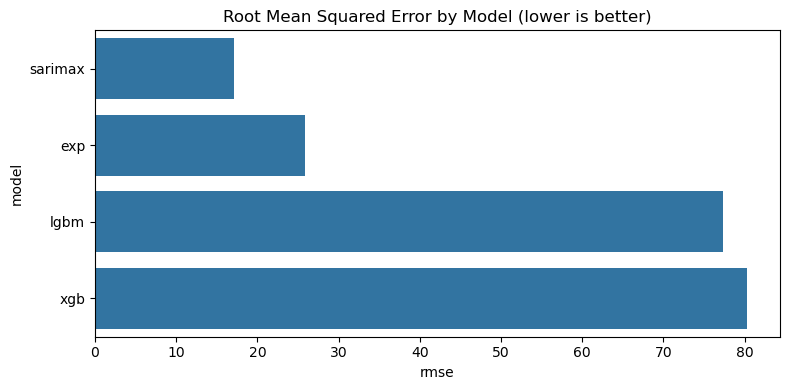

In [4]:
order = metrics.sort_values('rmse')['model']

plt.figure(figsize=(8,4))
sns.barplot(data=metrics, x='rmse', y='model', order=order)
plt.title('Root Mean Squared Error by Model (lower is better)')
plt.tight_layout()
plt.show()

## Comparing MAPE

MAPE is the most directly interpretable metric here - "on average, forecasts are off by X% of the actual passenger count" - and the one most worth leading with when explaining results to a non-technical audience.

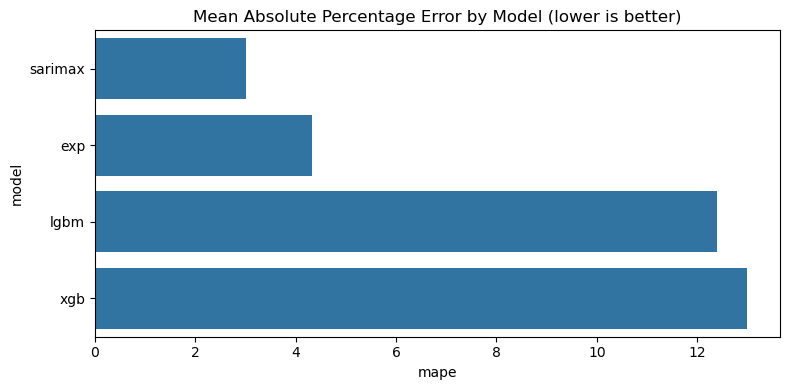

In [5]:
order = metrics.sort_values('mape')['model']

plt.figure(figsize=(8,4))
sns.barplot(data=metrics, x='mape', y='model', order=order)
plt.title('Mean Absolute Percentage Error by Model (lower is better)')
plt.tight_layout()
plt.show()

## Comparing MAE

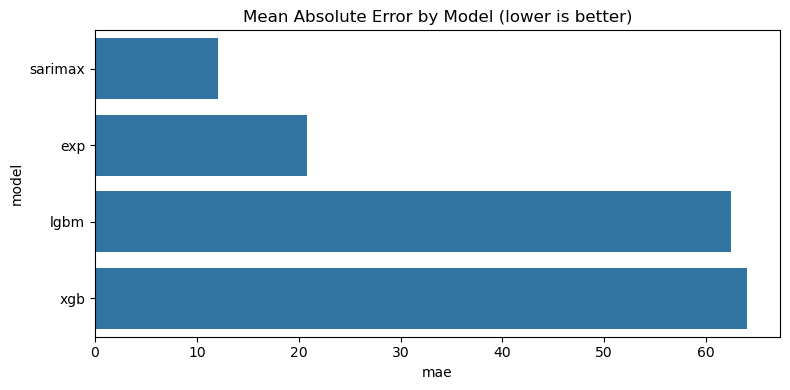

In [6]:
order = metrics.sort_values('mae')['model']

plt.figure(figsize=(8,4))
sns.barplot(data=metrics, x='mae', y='model', order=order)
plt.title('Mean Absolute Error by Model (lower is better)')
plt.tight_layout()
plt.show()

## Declaring a winner

R² isn't included in the ranking below - it's a weaker signal for time series forecasting than for standard regression, since it's built around explaining variance in i.i.d. data rather than extrapolation accuracy. MAE, MAPE, and RMSE all agree more directly on forecast quality, so ranking by MAPE (the most interpretable of the three) is the most defensible single number to lead with.

In [7]:
best_model = metrics.loc[metrics['mape'].idxmin(),'model']
best_mape = metrics['mape'].min()

print(f'Best model by MAPE: {best_model} ({best_mape}%)')
metrics.sort_values('mape').reset_index(drop=True)

Best model by MAPE: 0       lgbm
0        xgb
0        exp
0    sarimax
Name: model, dtype: object (3.0%)


,mae,mape,r2,rmse,model
0,12.04,3.00,0.95,17.07,sarimax
1,20.86,4.33,0.88,25.82,exp
2,62.46,12.40,-0.08,77.28,lgbm
3,64.06,13.00,-0.16,80.33,xgb
